In [305]:
import sys
sys.path.append('..')
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate  # TwoLocal, ZZFeatureMap, etc
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

In [311]:
service = QiskitRuntimeService(instance='client-enablement/solutions/demo-testing')
backend = service.backend("ibm_torino")

# target = backend.target
# cm = target.build_coupling_map()
cm = backend.coupling_map
deg3_qubits = [
    idx for idx, row in enumerate(cm.distance_matrix) if list(row).count(1) == 3
]
edge_qubits = [0, 2, 6, 10, 18, 32, 37, 51, 56, 70, 75, 89, 94, 108, 116, 120, 124]
full_layering = [
    [edge for edge in cm.get_edges() if d3q in edge]
    for d3q in deg3_qubits + edge_qubits
] # find all edges (i.e qubit tuples) containing any of the qubits in deg3 and edge qubits.
ent_map = sum(
    [[layer[idx] for layer in full_layering if idx < len(layer)] for idx in range(3)],
    [],
) 

def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()

#qubit_subset = [0, 1, 2, 3, 4, 14, 15, 18, 19, 20, 21, 22]
qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27] # trying 1 loop for torino
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# filtering the entanglement map such that only the desired qubits are present.
f_ent_map = []
for a, b in ent_map:
    if a in qubit_subset and b in qubit_subset:
        f_ent_map.append((remap[a], remap[b])) #maps it back to the qubits numbered 0 to 11.
H = Heisenberg(1, 12, f_ent_map)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    #
    qc.cx(9,10)
    #
    qc.cx(10,11)
    qc.cx(9,8)
    #
    qc.cx(11,6)
    qc.cx(8,7)
    #
    qc.cx(7,5)
    qc.cx(6,4)
    #
    qc.cx(4,3)
    qc.cx(5,0)
    #
    qc.cx(3,2)
    #make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    #undo entanglement on undesired qubits
    qc.cx(2,3)
    qc.cx(4,6)
    qc.cx(11,10)
    qc.cx(9,8)
    qc.cx(7,5)
    return qc

def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state='0')
    qc.cx(17, 11, ctrl_state='0')
    qc.cx(16,4, ctrl_state='0')
    qc.cx(15,2, ctrl_state='0')
    qc.cx(14,0, ctrl_state='0')
    qc.cx(13,7, ctrl_state='0')
    return qc



In [312]:
from qiskit.transpiler import generate_preset_pass_manager 

circuits = np.ndarray([10,10], dtype= QuantumCircuit)
H_tilde = np.zeros([10,10], dtype=complex)
S_tilde = np.zeros([10,10], dtype=complex)
synth = LieTrotter(reps = 1)
delta_t = np.pi/40
time_evol = PauliEvolutionGate(H, delta_t, synthesis = synth)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(10):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(10):
    circs.append([])
    for j in range(10):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]



In [313]:
#NO ANSATZ
#basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch
pub1=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[0:2] for circ in circ_list]
pub2=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[2:4] for circ in circ_list]
pub3=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[4:6] for circ in circ_list]
pub4=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[6:8] for circ in circ_list]
pub5=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[8:10] for circ in circ_list]

with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 10000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = 'XY4'
#     estimator.options.experimental = {"execution": {"fast_parametric_update": True}}
#     estimator.options.experimental = {
#     "execution_path": "ouroboros"
# }
    #estimator.options.execution.init_qubits=init_qubits
    # estimator.options.resilience.zne_mitigation = True
    # estimator.options.resilience.zne.noise_factors = (1, 1.5, 3) # also the default factors for pea.
    # estimator.options.resilience.zne.amplifier = 'pea'
    #estimator.options.twirling.enable_gates = True
    # estimator.options.twirling.num_randomizations = 32
    # estimator.options.twirling.shots_per_randomization = 350
    #estimator.options.twirling.strategy = 'active'
    # estimator.options.resilience.measure_mitigation = True
    # estimator.options.resilience.measure_noise_learning.num_randomizations = 32
    # estimator.options.resilience.measure_noise_learning.shots_per_randomization = (
    #     350
    # )
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)
    est_job_3 = estimator.run(pub3)
    est_job_4 = estimator.run(pub4)
    est_job_5 = estimator.run(pub5)

   

In [ ]:
est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

est_job_3_results = service.job(est_job_3.job_id()).result()

est_job_4_results = service.job(est_job_4.job_id()).result()

est_job_5_results = service.job(est_job_5.job_id()).result()


In [ ]:
idx=0
for i in range(2):
    for j in range(10):
            H_tilde[i,j] = est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(2,4):
    for j in range(10):
            H_tilde[i,j] = est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(4,6):
    for j in range(10):
            H_tilde[i,j] = est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(6,8):
    for j in range(10):
            H_tilde[i,j] = est_job_4_results[idx].data.evs[0] + 1j * est_job_4_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_4_results[idx].data.evs[2] + 1j * est_job_4_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(8,10):
    for j in range(10):
            H_tilde[i,j] = est_job_5_results[idx].data.evs[0] + 1j * est_job_5_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_5_results[idx].data.evs[2] + 1j * est_job_5_results[idx].data.evs[3]
            idx+=1

In [ ]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx] # the eigenvecs are normalized by default!
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    #make truncated matrix whose rows are eigenvectors of S-tilde with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T    
    return truncated_eigvecs

#solve diagonalization problem, find dependence on dimension of krylov subspace. 
def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        #solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps # the eigenvec in V are normalied.
        B = V_eps.conj().T @ S_temp @ V_eps
        print(A.shape[0])
        E, c = scipy.linalg.eig(a = A, b = B)
        idx = E.argsort()[::-1]   
        eigvals = E[idx]
        eigvecs = c[:,idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:,-1])
    return GSEs, ground_states, V_eps
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-18)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')

 ## Try Unitary AQC 

### Try MPF for the trotter evolution (?)

### Simulator results

In [ ]:
from qiskit.primitives import StatevectorEstimator

sv = StatevectorEstimator()


for j in range(10):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

circs = []
for i in range(10):
    circs.append([])
    for j in range(10):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

sv_job=sv.run([(circs[i][j], [real_obs_H, imag_obs_H,real_obs_S, imag_obs_S]) for i in range(10) for j in range(10)])

In [232]:
sv_res = sv_job.result()

In [243]:
[S_tilde[i][i] for i in range(10)]

[np.complex128(0.9999999999999998+0j),
 np.complex128(0.9999999999999993+0j),
 np.complex128(0.9999999999999982+0j),
 np.complex128(0.9999999999999971+0j),
 np.complex128(0.9999999999999959+0j),
 np.complex128(0.9999999999999951+0j),
 np.complex128(0.9999999999999942+0j),
 np.complex128(0.9999999999999928+0j),
 np.complex128(0.9999999999999917+0j),
 np.complex128(0.9999999999999906+0j)]

In [242]:
[H_tilde[i][i] for i in range(10)]

[np.complex128(-13.999999999999998+0j),
 np.complex128(-14.217085424350893+4.9213164806890565e-16j),
 np.complex128(-14.032798020241032+3.596298606134418e-16j),
 np.complex128(-13.720496449230465-2.2898349882893854e-16j),
 np.complex128(-13.670406629804438-2.465190328815662e-32j),
 np.complex128(-13.873154844452438-8.326672684688672e-17j),
 np.complex128(-13.944526804466015-1.3183898417423731e-16j),
 np.complex128(-13.666382792703459+8.391724815037806e-17j),
 np.complex128(-13.307103334420024+2.92300905702092e-16j),
 np.complex128(-13.281968821336287-5.392143979585096e-16j)]

1
2
3
4
5
6
7
8
9


Text(0, 0.5, 'Ground state energy')

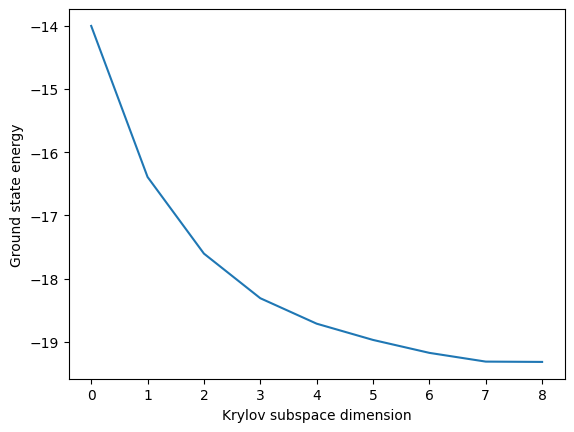

In [251]:
idx=0
for i in range(10):
    for j in range(10):
            H_tilde[i,j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
            S_tilde[i,j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
            idx+=1


def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx] # the eigenvecs are normalized by default!
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    #make truncated matrix whose rows are eigenvectors of S-tilde with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T    
    return truncated_eigvecs

#solve diagonalization problem, find dependence on dimension of krylov subspace. 
def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        #solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps # the eigenvec in V are normalied.
        B = V_eps.conj().T @ S_temp @ V_eps
        print(A.shape[0])
        E, c = scipy.linalg.eig(a = A, b = B)
        idx = E.argsort()[::-1]   
        eigvals = E[idx]
        eigvecs = c[:,idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:,-1])
    return GSEs, ground_states, V_eps
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-18)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')

### Try differently

In [374]:
# service = QiskitRuntimeService(instance='client-enablement/solutions/demo-testing')
# backend = service.backend("ibm_torino")

# target = backend.target
# cm = target.build_coupling_map()
qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27] # trying 1 loop for torino
rev_map = {val:key for key,val in remap.items()}

cm= backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a,b) if a<b else (b,a) for a,b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i,j in edge_list]




def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()
H = Heisenberg(1, 12, edge_list)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    #
    qc.cx(9,10)
    #
    qc.cx(10,11)
    qc.cx(9,8)
    #
    qc.cx(11,6)
    qc.cx(8,7)
    #
    qc.cx(7,5)
    qc.cx(6,4)
    #
    qc.cx(4,3)
    qc.cx(5,0)
    #
    qc.cx(3,2)
    #make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    #undo entanglement on undesired qubits
    qc.cx(2,3)
    qc.cx(4,6)
    qc.cx(11,10)
    qc.cx(9,8)
    qc.cx(7,5)
    return qc

def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state='0')
    qc.cx(17, 11, ctrl_state='0')
    qc.cx(16,4, ctrl_state='0')
    qc.cx(15,2, ctrl_state='0')
    qc.cx(14,0, ctrl_state='0')
    qc.cx(13,7, ctrl_state='0')
    return qc



In [375]:
from qiskit.transpiler import generate_preset_pass_manager 

t_steps = 4
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
synth = LieTrotter(reps = 1)
delta_t = np.pi/40
time_evol = PauliEvolutionGate(H, delta_t, synthesis = synth)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]



In [380]:
f'Max circuit depth: {max([circs[i][j].depth(lambda x: len(x.qubits)>=2) for i in range(t_steps) for j in range(t_steps)])}'

'Max circuit depth: 34'

In [ ]:
f'Max number of 2q gates= {max([circs[i][j].num_nonlocal_gates() for i in range(t_steps) for j in range(t_steps)])}'

'Max number of 2q gates: 135'

### Circuit execution

In [392]:
#basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch
pub1=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[0:2] for circ in circ_list]
pub2=[(circ,[real_obs_H.apply_layout(circ.layout), 
                                     imag_obs_H.apply_layout(circ.layout), 
                                     real_obs_S.apply_layout(circ.layout), 
                                     imag_obs_S.apply_layout(circ.layout)]) for circ_list in circs[2:4] for circ in circ_list]

# Experiment options
num_randomizations = 300
num_randomizations_learning = 20
max_batch_circuits = 20
shots_per_randomization = 100
learning_pair_depths = [0, 4, 24]
noise_factors = [1, 1.3, 1.6]

# Base option formatting
options = {
    # Builtin resilience settings for ZNE
    "resilience": {
        "measure_mitigation": True,
        "zne_mitigation": True,
        "zne": {"noise_factors": noise_factors},

        # TREX noise learning configuration
        "measure_noise_learning": {
            "num_randomizations": num_randomizations_learning,
            "shots_per_randomization": shots_per_randomization,
        },
        
        # PEA noise model configuration
        "layer_noise_learning": {
            "max_layers_to_learn": 10,
            "layer_pair_depths": learning_pair_depths,
            "shots_per_randomization": shots_per_randomization,
            "num_randomizations": num_randomizations_learning,
        },
    },
    
    # Randomization configuration
    "twirling": {
        "num_randomizations": num_randomizations,
        "shots_per_randomization": shots_per_randomization,
        "strategy": "all",
    },

    # Experimental settings for PEA method
    "experimental": {
        # # Just in case, disable any further qiskit transpilation not related to twirling / DD
        # "skip_transpilation": True,

        # Execution configuration
        "execution": {
            "max_pubs_per_batch_job": max_batch_circuits,
            "fast_parametric_update": True,
        },

        # Error Mitigation configuration
        "resilience": {
            # ZNE Configuration
            "zne": {
                "amplifier": "pea",
                "return_all_extrapolated": True,
                "return_unextrapolated": True,
                "extrapolated_noise_factors": [0] + noise_factors,
            }
        }
    }
}


with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch, options=options)
    #estimator.options.default_shots = 12000
    #estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = 'XY4'
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)


   

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:830: UserWarning: The backend ibm_torino currently has a status of internal.
  warnings.warn(


In [401]:
est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/qiskit/qpy/interface.py:333: UserWarning: The qiskit version used to generate the provided QPY file, 1.4.1, is newer than the current qiskit version 1.3.2. This may result in an error if the QPY file uses instructions not present in this current qiskit version
  warnings.warn(


In [403]:
idx=0
for i in range(2):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
            idx+=1

idx=0
for i in range(2,4):
    for j in range(t_steps):
            H_tilde[i,j] = est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
            S_tilde[i,j] = est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
            idx+=1

In [404]:
S_tilde

array([[ 0.22095338-0.04511681j, -0.0058594 +0.5720048j ,
        -0.78029095-0.06432384j,  0.01134631+0.05407916j],
       [-0.12460035+0.69623346j,  1.04660091+0.04942982j,
        -0.00338664+0.63005991j, -0.32660681-0.11818639j],
       [-0.08212918-0.0291811j , -0.00627796+0.2665507j ,
         0.23516902+0.06866791j, -0.0089176 +0.28760764j],
       [ 0.48722745-0.00164991j, -0.08197599-0.02193814j,
        -0.01918749+0.23388978j,  0.25756857-0.00884897j]])

In [405]:
H_tilde

array([[-2.48736524+2.00893648j,  5.75189669-7.97406957j,
         5.30467191+3.08541301j, -3.52494944-0.22052125j],
       [ 5.31695374-8.31817205j, -9.32836952-0.70915581j,
         3.07343559-7.4728699j ,  0.86780247+4.5356639j ],
       [ 2.4767276 +3.36326605j,  1.60871257-2.920559j  ,
        -3.41409753-0.52619925j,  1.44926846-2.26461159j],
       [-1.27177098+0.33577709j,  1.79734294+1.97469926j,
         1.01326232-2.78401292j, -3.49909254-0.04070561j]])

1
2
3
GSE`s: [np.complex128(-12.589066229207798+6.521547655048862j), np.complex128(-16.243320932605574-1.8726040460408695j), np.complex128(-18.377244053342533+4.3122217002900936j)]


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

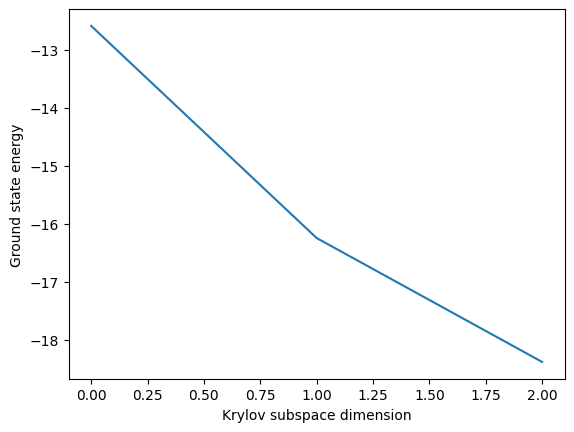

In [410]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
print(f'GSE`s: {GSEs}')
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')

In [393]:
# run on simulator for comparison


from qiskit.transpiler import generate_preset_pass_manager 

t_steps = 4
circuits = np.ndarray([t_steps,t_steps], dtype= QuantumCircuit)
H_tilde = np.zeros([t_steps,t_steps], dtype=complex)
S_tilde = np.zeros([t_steps,t_steps], dtype=complex)
synth = LieTrotter(reps = 1)
delta_t = np.pi/40
time_evol = PauliEvolutionGate(H, delta_t, synthesis = synth)

real_obs_H = SparsePauliOp('XXXXXX', 1) ^ H 
imag_obs_H = SparsePauliOp('YXXXXX', 1) ^ H
real_obs_S = SparsePauliOp('XXXXXX', 1) ^ SparsePauliOp('I'*12, 1)
imag_obs_S = SparsePauliOp('YXXXXX', 1) ^ SparsePauliOp('I'*12, 1)



for j in range(t_steps):
    for i in range(j+1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

#circs = [pm.run(circ) for circ in circs]



sv_job=sv.run([(circs[i][j], [real_obs_H, imag_obs_H,real_obs_S, imag_obs_S]) for i in range(t_steps) for j in range(t_steps)])

sv_res = sv_job.result()

In [400]:
idx=0
for i in range(t_steps):
    for j in range(t_steps):
            H_tilde[i,j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
            S_tilde[i,j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
            idx+=1
print(H_tilde)

print(S_tilde)

[[-12.        +0.00000000e+00j   6.44605962-9.32576050e+00j
    3.23814767+8.53998277e+00j  -5.5527575 -2.01013286e+00j]
 [  6.44605962-9.32576050e+00j -11.96300088+3.38552379e-16j
    6.43232415-9.26373005e+00j   3.18151687+8.50887092e+00j]
 [  3.23814767+8.53998277e+00j   6.43232415-9.26373005e+00j
  -11.86784426-5.46401288e-16j   6.40985317-9.16623135e+00j]
 [ -5.5527575 -2.01013286e+00j   3.18151687+8.50887092e+00j
    6.40985317-9.16623135e+00j -11.75405599+1.85156366e-16j]]
[[ 1.        +0.j         -0.26633086+0.8196821j  -0.40786385-0.36717711j
   0.2595403 -0.03745379j]
 [-0.26633086+0.8196821j   1.        +0.j         -0.26633086+0.8196821j
  -0.40786385-0.36717711j]
 [-0.40786385-0.36717711j -0.26633086+0.8196821j   1.        +0.j
  -0.26633086+0.8196821j ]
 [ 0.2595403 -0.03745379j -0.40786385-0.36717711j -0.26633086+0.8196821j
   1.        +0.j        ]]


1
2
3


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

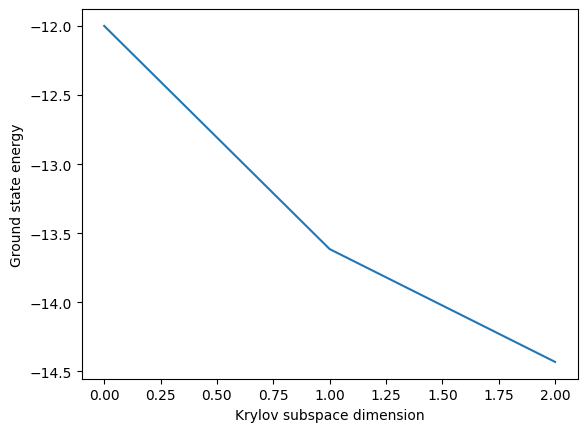

In [399]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs) # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel('Krylov subspace dimension')
plt.ylabel('Ground state energy')